In [3]:
%pip install tabulate

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.optimize import minimize
import pickle
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [29]:
################ Load model results
# Demand model results
with open('demand_model_results.pkl', 'rb') as f:
     demand_param = pickle.load(f)

# Charging station model results
with open('charging_station_model_results.pkl', 'rb') as f:
     charging_param = pickle.load(f)

# Import data
df = pd.read_csv('demand_counterfactual.csv')
supply = pd.read_csv('supply_counterfactual.csv')

# Calculate number of new stations using charging_stations_stock_lag directly
df['new_stations'] = df['charging_stations_stock'] - df['charging_stations_stock_lag']

# Add EV_stock from supply to df if columns exist
if 'year' in df.columns and 'province' in df.columns:
    df = df.merge(supply[['year', 'province', 'EV_stock']], on=['year', 'province'], how='left')
else:
    print("Either 'year' or 'province' column is missing in df. Please check your data.")

# Ensure required columns are present in df by merging from supply if missing
required_cols = ['sub_fix', 'sub_ope', 'time_trend', 'num_models_in_market', 'sales_weighted_avg_range']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
	df = df.merge(
		supply[['year', 'province'] + missing_cols],
		on=['year', 'province'],
		how='left'
	)

In [22]:
def create_ev_only_subsidy_scenario(df, sub=0, nat=0, PHEV=0, BEV1=0, BEV2=0, BEV3=0, t=1):
    """
    Create a counterfactual scenario where only EVs (BEV and PHEV) receive subsidies.
    Gas vehicles get all subsidies set to 0.
    
    Parameters:
    - df: DataFrame with the data
    - sub, nat, PHEV, BEV1, BEV2, BEV3, t: subsidy values for EVs
    - gas_tax: Tax rate for Gas vehicles (if None, uses original tax rate from data)
    
    Returns:
    - List of dicts for each observation, with subsidies set appropriately
    """
    counterfactual_scenario = []
    
    for _, row in df.iterrows():
        if row['fuel_type'] == 'Gas':
            # Gas vehicles get no subsidies
            scenario_dict = {
                'sub': 0,
                'nat': 0,
                'PHEV': 0,
                'BEV1': 0,
                'BEV2': 0,
                'BEV3': 0,
                't': 1
            }
        else:
            # EVs (BEV and PHEV) get the specified subsidies
            scenario_dict = {
                'sub': sub,
                'nat': nat,
                'PHEV': PHEV,
                'BEV1': BEV1,
                'BEV2': BEV2,
                'BEV3': BEV3,
                't': t,
            }
        counterfactual_scenario.append(scenario_dict)
    
    return counterfactual_scenario

In [23]:
# Nested net price function
def compute_net_price(share, manual_subsidy=None):
    rg = share['range']
    p = share['prices']
    
    if manual_subsidy is not None:
        # Use manual_subsidy values, with proper defaults for missing keys
        sub = manual_subsidy.get('sub', 0)  # Default to 0, not original data
        nat = manual_subsidy.get('nat', 0)  # Default to 0, not original data
        PHEV = manual_subsidy.get('PHEV', 0) if share['fuel_type'] == 'PHEV' else 0
        BEV1 = manual_subsidy.get('BEV1', 0) if share['fuel_type'] == 'BEV' else 0
        BEV2 = manual_subsidy.get('BEV2', 0) if share['fuel_type'] == 'BEV' else 0
        BEV3 = manual_subsidy.get('BEV3', 0) if share['fuel_type'] == 'BEV' else 0
        t = manual_subsidy.get('t', 1)  # Default to 1, not original data
    else:
        # Use original data values
        sub = share['sub']
        nat = share['nat']
        PHEV = share['sub_PHEV'] if share['fuel_type'] == 'PHEV' else 0
        BEV1 = share['sub_BEV_1'] if share['fuel_type'] == 'BEV' else 0
        BEV2 = share['sub_BEV_2'] if share['fuel_type'] == 'BEV' else 0
        BEV3 = share['sub_BEV_3'] if share['fuel_type'] == 'BEV' else 0
        t = share['Tax']
    
    def range_category(r, BEV1, BEV2, BEV3):
        if 250 <= r < 300:
            return BEV1
        elif 300 <= r < 400:
            return BEV2
        elif 400 <= r:
            return BEV3
        else:
            return 0
    
    BEV = range_category(rg, BEV1, BEV2, BEV3)

    if nat == 0:
        return p * t - sub - PHEV - BEV
    elif nat == 1:
        return p * t - nat * 10000 * sub * (BEV + PHEV) - PHEV - BEV
    else:
        return p * t  # When nat is neither 0 nor 1

In [24]:
def compute_delta_jm(X_jm, demand_par, purchase_subsidy=None, counterfactual_subsidy=None):
    """
    Compute mean utilities δ_jm for nested logit model:
    δ_jm = β_price * net_prices + β_range * range + β_power * power + β_battery * battery_capacity 
           + β_EV * is_electric + β_N * log_charging_stock_hat 
           + β_N_EV * (is_electric × log_charging_stock_hat) + ξ_jm

    If purchase_subsidy is provided (array-like, same length as X_jm), it will be subtracted from net_prices
    to allow counterfactuals with different purchase subsidy levels.

    If counterfactual_subsidy is provided (list of dicts, same length as X_jm), it will be used to override the subsidy
    for each observation (e.g., set to 0 for no subsidy scenario).
    """
    # Copy to avoid modifying original DataFrame
    X = X_jm.copy()

    # If counterfactual_subsidy is provided, use it to override subsidy in net price calculation
    if counterfactual_subsidy is not None:
        X['net_prices'] = [
            compute_net_price(row, manual_subsidy=counterfactual_subsidy[i])
            for i, row in X.iterrows()
        ]
        if purchase_subsidy is not None:
            X['net_prices'] = X['net_prices'] - purchase_subsidy
    elif purchase_subsidy is not None:
        X['net_prices'] = X['net_prices'] - purchase_subsidy

    # Use log_charging_stock_hat instead of log_charging_stock to match demand model
    X['log_charging_stock_hat'] = X['log_charging_stock']
    
    # Compute utility following the exact demand model specification
    delta_jm = (
        demand_par.params['net_prices'] * X['net_prices'] +
        demand_par.params['range'] * X['range'] +
        demand_par.params['power'] * X['power'] +
        demand_par.params['battery_capacity'] * X['battery_capacity'] +
        demand_par.params['is_electric'] * X['is_electric'] +
        demand_par.params['log_charging_stock_hat'] * X['log_charging_stock_hat'] +
        demand_par.params['is_electric:log_charging_stock_hat'] * (X['is_electric'] * X['log_charging_stock_hat']) +
        demand_par.resids
    )
    
    return delta_jm


In [25]:
################ Nested logit shares
def nested_logit_shares(delta_jm, rho, group_membership, market_ids=None):
    """
    Compute nested logit predicted shares for every product in every market,
    using mean utilities of all product-market pairs.

    Parameters
    ----------
    delta_jm : array-like
        Mean utilities for all product-market pairs (length = number of rows in df)
    rho : float
        Nesting parameter (0 ≤ ρ < 1)
    group_membership : array-like
        Nest assignment for each product-market pair (same length as delta_jm)
    market_ids : array-like or None
        Market assignment for each product-market pair (same length as delta_jm).
        If None, treats all rows as one market.

    Returns
    -------
    s_j : np.ndarray
        Share for each product-market pair (same order as input)
    s_0 : np.ndarray
        Outside good share for each market (same order as unique market_ids)
    """
    delta_jm = np.array(delta_jm)
    group_membership = np.array(group_membership)
    if market_ids is None:
        market_ids = np.zeros(len(delta_jm), dtype=int)
    else:
        market_ids = np.array(market_ids)

    s_j = np.zeros_like(delta_jm)
    unique_markets = np.unique(market_ids)
    s_0 = np.zeros(len(unique_markets))

    for i, m in enumerate(unique_markets):
        mask_market = (market_ids == m)
        delta_m = delta_jm[mask_market]
        group_m = group_membership[mask_market]
        unique_groups = np.unique(group_m)
        D_g = {}
        for g in unique_groups:
            mask_g = (group_m == g)
            D_g[g] = np.sum(np.exp(delta_m[mask_g] / (1 - rho)))
        log_ratio = np.zeros_like(delta_m)
        for j, (delta, g) in enumerate(zip(delta_m, group_m)):
            log_ratio[j] = delta / (1 - rho) - rho * np.log(D_g[g])
        sum_exp = np.sum(np.exp(log_ratio))
        s_0[i] = 1 / (1 + sum_exp)
        s_j[mask_market] = np.exp(log_ratio) * s_0[i]

    return s_j, s_0

In [26]:
################ Function to compute total spendings on subsidies
def calculate_total_gov_spending(df, sales, net_prices, purchase_subsidy, sub_fix, sub_ope, N_market, new_piles):
    """
    Calculate total government spending on subsidies:
    - Demand subsidies: difference between prices and net_prices for each sale  
    - Purchase subsidies: purchase_subsidy * sales (if provided)
    - Charging subsidies: avg_charging * N_market + sub_fix * new_stations
    """
    # Ensure arrays are same length as df
    if len(sales) != len(df):
        raise ValueError(f"Sales length {len(sales)} doesn't match df length {len(df)}")
    
    # Product-level spending (vehicle sales subsidies) 
    purchase_subsidy = purchase_subsidy if purchase_subsidy is not None else np.zeros(len(df))
    if isinstance(purchase_subsidy, (int, float)):
        purchase_subsidy = np.full(len(df), purchase_subsidy)
    
    # Calculate subsidy per vehicle sold
    price_diff = df['prices'].values - np.array(net_prices)
    gov_spending_product = sales * price_diff + purchase_subsidy * sales
    
    # Market-level spending (charging station subsidies) - ensure proper broadcasting
    if isinstance(sub_fix, (int, float)):
        sub_fix = np.full(len(N_market), sub_fix)
    if isinstance(sub_ope, (int, float)): 
        sub_ope = np.full(len(N_market), sub_ope)
        
    # Ensure all arrays have same length
    assert len(sub_fix) == len(N_market), f"sub_fix length {len(sub_fix)} != N_market length {len(N_market)}"
    assert len(sub_ope) == len(N_market), f"sub_ope length {len(sub_ope)} != N_market length {len(N_market)}"
    assert len(new_piles) == len(N_market), f"new_piles length {len(new_piles)} != N_market length {len(N_market)}"
    
    # Operating subsidy per charging station
    avg_charging = 24 * 0.13 * 60 * 365 * sub_ope  # Operating subsidy per charging stick
    gov_spending_market = avg_charging * N_market + sub_fix * new_piles
    
    # Total spending (convert to same units)
    total_spending = np.sum(gov_spending_product) * 10000 + np.sum(gov_spending_market)
    
    return total_spending

In [27]:
################ Fixed-point iteration for EV-station equilibrium
def fixed_point_iteration(
    design_matrix_init,
    demand_par,
    charging_par,
    rho,
    group_membership,
    max_iter=100,
    tol=1e-6,
    demand_subsidy=None,    # 1. Counterfactual demand-side subsidy (list of dicts for compute_delta_jm)
    purchase_subsidy=None,  # 2. Counterfactual purchase subsidy (array for compute_delta_jm)
    supply_subsidy=None     # 3. Counterfactual supply-side subsidy (mask for charging stations)
):
    """
    Fixed-point iteration for EV-station equilibrium at the market level.
    demand_subsidy: list of dicts, one per row, passed to compute_delta_jm as counterfactual_subsidy.
    purchase_subsidy: array-like, same length as df, passed to compute_delta_jm as purchase_subsidy.
    supply_subsidy: dict, DataFrame, array, or list, specifying which markets have supply-side subsidies.
    """
    df = design_matrix_init.copy()
    market_ids = df['market_ids'].values
    unique_markets = np.unique(market_ids)

    # Initialize N and Q_ev for each market (take first occurrence in each market)
    N_market = df.groupby('market_ids')['charging_stations_stock'].first().reindex(unique_markets).values
    Q_ev_market = df.groupby('market_ids')['EV_stock'].first().reindex(unique_markets).values
    Q_ev_stock = df.groupby('market_ids')['EV_stock'].first().reindex(unique_markets).values

    history = {'N': [], 'Q_ev': [], 'delta': []}

    for iteration in range(max_iter):
        # Assign current market-level N and Q_ev to all rows
        market_idx_map = {m: i for i, m in enumerate(unique_markets)}
        df['N_market'] = [N_market[market_idx_map[m]] for m in market_ids]
        df['Q_ev_market'] = [Q_ev_market[market_idx_map[m]] for m in market_ids]
        df['charging_stations_stock'] = df['N_market']
        df['EV_stock'] = df['Q_ev_market']
        # Remove +1 to match original model specification
        df['log_charging_stock'] = np.log(df['charging_stations_stock'])

        # Compute mean utilities with counterfactual demand and purchase subsidies
        delta = compute_delta_jm(
            df,
            demand_par,
            purchase_subsidy=purchase_subsidy,
            counterfactual_subsidy=demand_subsidy
        )

        # Compute shares for each product-market
        s_j, _ = nested_logit_shares(delta, rho, group_membership, market_ids=market_ids)

        # Update EV stock for each market by summing EV sales in that market
        ev_mask = df['is_electric'].values == 1
        market_size = df['market_size'].values if 'market_size' in df.columns else np.ones_like(s_j)
        sales = s_j * market_size
        ev_sales = sales * ev_mask
        df['ev_sales'] = ev_sales
        Q_ev_market_new = df.groupby('market_ids')['ev_sales'].sum().reindex(unique_markets).values + Q_ev_stock

        # Update station stock for each market using the supply model
        supply_covs = df.drop_duplicates('market_ids').set_index('market_ids').reindex(unique_markets)
        if supply_subsidy is not None:
            # Ensure supply_subsidy is properly broadcast to match unique_markets length
            if isinstance(supply_subsidy, (list, tuple)) and len(supply_subsidy) == 2:
                sub_fix = np.full(len(unique_markets), supply_subsidy[0])
                sub_ope = np.full(len(unique_markets), supply_subsidy[1])
            else:
                sub_fix = supply_subsidy[0]
                sub_ope = supply_subsidy[1]
        else:
            sub_fix = supply_covs['sub_fix'].values.copy()
            sub_ope = supply_covs['sub_ope'].values.copy()

        # Initialize log_N with base terms - remove +1 to match original model
        log_N = (
            charging_par.params['log(EV_stock)'] * np.log(Q_ev_market_new) +
            charging_par.params['sub_fix'] * sub_fix +
            charging_par.params['sub_ope'] * sub_ope +
            charging_par.params['time_trend'] * supply_covs['time_trend'].values
        )
        
        # Add residuals - ensure shape compatibility
        if hasattr(charging_par, 'resids') and charging_par.resids is not None:
            resids = charging_par.resids
            if len(resids) == len(unique_markets):
                log_N += resids
            else:
                # If residuals don't match markets, use appropriate subset or skip
                print(f"Warning: Residuals shape {len(resids)} doesn't match markets {len(unique_markets)}")
                # Try to use first len(unique_markets) residuals if available
                if len(resids) >= len(unique_markets):
                    log_N += resids[:len(unique_markets)]
        
        # Add province fixed effects with improved parsing
        for k in charging_par.params.keys():
            if k.startswith('C(province)'):
                # Handle both [T.province] and [province] formats
                if '[T.' in k:
                    province = k.split('[T.')[1].rstrip(']')
                elif '[' in k and ']' in k:
                    province = k.split('[')[1].rstrip(']')
                else:
                    continue  # Skip if can't parse
                
                # Create boolean mask and ensure proper broadcasting
                mask = (supply_covs['province'] == province).astype(float).values
                if len(mask) == len(unique_markets):
                    log_N += charging_par.params[k] * mask
        
        # Remove year fixed effects as they're not in the original supply model specification
        # The original model only includes time_trend, not year fixed effects

        N_market_new = np.exp(log_N)

        # Check convergence
        delta_N = np.max(np.abs(N_market_new - N_market))
        delta_Q = np.max(np.abs(Q_ev_market_new - Q_ev_market))
        history['N'].append(N_market_new.copy())
        history['Q_ev'].append(Q_ev_market_new.copy())
        history['delta'].append(max(delta_N, delta_Q))

        if delta_N < tol and delta_Q < tol:
            print(f"Converged after {iteration+1} iterations")
            break

        # Update for next iteration
        N_market = N_market_new
        Q_ev_market = Q_ev_market_new
        
        # Fix new_station calculation - ensure proper alignment
        charging_stock_lag = df.groupby('market_ids')['charging_stations_stock_lag'].first().reindex(unique_markets).values
        new_station = N_market - charging_stock_lag
        
        if demand_subsidy is not None:
            net_prices = [
                compute_net_price(row, manual_subsidy=demand_subsidy[i])
                for i, (idx, row) in enumerate(df.iterrows())
            ]
        else:
            net_prices = df['prices'].values

        # Call compute_total_gov_spending to calculate total government spending
        Gov_spending = calculate_total_gov_spending(
            df,
            sales,
            net_prices,
            purchase_subsidy,
            sub_fix,  # Already properly sized for unique_markets
            sub_ope,  # Already properly sized for unique_markets  
            N_market,
            new_station
        )
    else:
        print(f"Warning: Max iterations ({max_iter}) reached")

    return {
        'N': N_market,
        'Q_ev': Q_ev_market,
        'shares': s_j,
        'history': pd.DataFrame(history),
        'Gov_spending': Gov_spending,
    }

In [10]:
################ Compute counterfactual scenarios
# 0. No subsidies: set all subsidies to 0 for EVs, Gas vehicles already have 0 subsidies
demand_counterfactual_0 = create_ev_only_subsidy_scenario(
    df, 
    sub=0, nat=0, 
    PHEV=0, BEV1=0, BEV2=0, BEV3=0, 
    t=1
)

supply_subsidy_0 = [0,0]

result_0 = fixed_point_iteration(
    df,
    demand_param,
    charging_param,
    demand_param.params['log_sj_g'],
    df['nesting_ids'].values,
    max_iter=100,
    tol=1e-6,
    demand_subsidy=demand_counterfactual_0,    # 1. Counterfactual demand-side subsidy (list of dicts for compute_delta_jm)
    purchase_subsidy=None,  # 2. Counterfactual purchase subsidy (array for compute_delta_jm)
    supply_subsidy=supply_subsidy_0     # 3. Counterfactual supply-side subsidy (mask for charging stations)
)

Converged after 13 iterations


In [11]:
# 1. Only range-based subsidies for EVs
demand_counterfactual_1 = create_ev_only_subsidy_scenario(
    df, 
    sub=0, nat=0, 
    PHEV=1.0, BEV1=1.8, BEV2=1.8, BEV3=2.5, 
    t=1
)

supply_subsidy_1 = [0,0]

result_1 = fixed_point_iteration(
    df,
    demand_param,
    charging_param,
    demand_param.params['log_sj_g'],
    df['nesting_ids'].values,
    max_iter=100,
    tol=1e-6,
    demand_subsidy=demand_counterfactual_1,    # 1. Counterfactual demand-side subsidy (list of dicts for compute_delta_jm)
    purchase_subsidy=None,  # 2. Counterfactual purchase subsidy (array for compute_delta_jm)
    supply_subsidy=supply_subsidy_1     # 3. Counterfactual supply-side subsidy (mask for charging stations)
)

Converged after 13 iterations


In [12]:
# 2. Only station subsidies
demand_counterfactual_2 = create_ev_only_subsidy_scenario(
    df, 
    sub=0, nat=0, 
    PHEV=0, BEV1=0, BEV2=0, BEV3=0, 
    t=1
)

supply_subsidy_2 = [0,0.5]

result_2 = fixed_point_iteration(
    df,
    demand_param,
    charging_param,
    demand_param.params['log_sj_g'],
    df['nesting_ids'].values,
    max_iter=100,
    tol=1e-6,
    demand_subsidy=demand_counterfactual_2,    # 1. Counterfactual demand-side subsidy (list of dicts for compute_delta_jm)
    purchase_subsidy=None,  # 2. Counterfactual purchase subsidy (array for compute_delta_jm)
    supply_subsidy=supply_subsidy_2     # 3. Counterfactual supply-side subsidy (mask for charging stations)
)

Converged after 12 iterations


In [13]:
# 3. Added purchase subsidies only
demand_counterfactual_3 = create_ev_only_subsidy_scenario(
    df, 
    sub=0, nat=0, 
    PHEV=0, BEV1=0, BEV2=0, BEV3=0, 
    t=1
)

supply_subsidy_3 = [0,0]

purchase_subsidy_3 = np.array([
    2 if row['fuel_type'] in ['BEV', 'PHEV'] else 0 
    for _, row in df.iterrows()
])

result_3 = fixed_point_iteration(
    df,
    demand_param,
    charging_param,
    demand_param.params['log_sj_g'],
    df['nesting_ids'].values,
    max_iter=100,
    tol=1e-6,
    demand_subsidy=demand_counterfactual_3,    # 1. Counterfactual demand-side subsidy (list of dicts for compute_delta_jm)
    purchase_subsidy=purchase_subsidy_3,  # 2. Counterfactual purchase subsidy (array for compute_delta_jm)
    supply_subsidy=supply_subsidy_3     # 3. Counterfactual supply-side subsidy (mask for charging stations)
)

Converged after 14 iterations


In [14]:
# 4. Tax only
demand_counterfactual_4 = create_ev_only_subsidy_scenario(
    df, 
    sub=0, nat=0, 
    PHEV=0, BEV1=0, BEV2=0, BEV3=0, 
    t=0.911,  # Tax reduction only for EVs
)

supply_subsidy_4 = [0,0]

purchase_subsidy_4 = None

result_4 = fixed_point_iteration(
    df,
    demand_param,
    charging_param,
    demand_param.params['log_sj_g'],
    df['nesting_ids'].values,
    max_iter=100,
    tol=1e-6,
    demand_subsidy=demand_counterfactual_4,    # 1. Counterfactual demand-side subsidy (list of dicts for compute_delta_jm)
    purchase_subsidy=purchase_subsidy_4,  # 2. Counterfactual purchase subsidy (array for compute_delta_jm)
    supply_subsidy=supply_subsidy_4     # 3. Counterfactual supply-side subsidy (mask for charging stations)
)

Converged after 13 iterations


In [19]:
# 5. All subsidies as before
demand_counterfactual_5 = create_ev_only_subsidy_scenario(
    df, 
    sub=df.loc[df['fuel_type'].isin(['BEV', 'PHEV']), 'sub'].iloc[0] if len(df.loc[df['fuel_type'].isin(['BEV', 'PHEV'])]) > 0 else 0, 
    nat=df.loc[df['fuel_type'].isin(['BEV', 'PHEV']), 'nat'].iloc[0] if len(df.loc[df['fuel_type'].isin(['BEV', 'PHEV'])]) > 0 else 0,
    PHEV=df.loc[df['fuel_type'] == 'PHEV', 'sub_PHEV'].iloc[0] if len(df.loc[df['fuel_type'] == 'PHEV']) > 0 else 0,
    BEV1=df.loc[df['fuel_type'] == 'BEV', 'sub_BEV_1'].iloc[0] if len(df.loc[df['fuel_type'] == 'BEV']) > 0 else 0,
    BEV2=df.loc[df['fuel_type'] == 'BEV', 'sub_BEV_2'].iloc[0] if len(df.loc[df['fuel_type'] == 'BEV']) > 0 else 0,
    BEV3=df.loc[df['fuel_type'] == 'BEV', 'sub_BEV_3'].iloc[0] if len(df.loc[df['fuel_type'] == 'BEV']) > 0 else 0,
    t=df.loc[df['fuel_type'].isin(['BEV', 'PHEV']), 'Tax'].iloc[0] if len(df.loc[df['fuel_type'].isin(['BEV', 'PHEV'])]) > 0 else 1
)

supply_subsidy_5 = None

# Create purchase subsidy array: only EVs get the subsidy
purchase_subsidy_5 = None

result_5 = fixed_point_iteration(
    df,
    demand_param,
    charging_param,
    demand_param.params['log_sj_g'],
    df['nesting_ids'].values,
    max_iter=100,
    tol=1e-6,
    demand_subsidy=demand_counterfactual_5,    # 1. Counterfactual demand-side subsidy (list of dicts for compute_delta_jm)
    purchase_subsidy=purchase_subsidy_5,  # 2. Counterfactual purchase subsidy (array for compute_delta_jm)
    supply_subsidy=supply_subsidy_5     # 3. Counterfactual supply-side subsidy (mask for charging stations)
)

Converged after 14 iterations


In [ ]:
# Compute total EV sales and total N for all markets across all years, display only these two measures and government spending in relative terms to no-incentive case

def get_totals(result, df):
    # Sum across ALL markets (all years) instead of filtering for specific year
    total_ev_sales = np.sum(result['Q_ev'])
    total_N_all_years = np.sum(result['N'])  # Sum all markets across all years
    gov_spending = result['Gov_spending']
    return total_ev_sales, total_N_all_years, gov_spending

# Get totals for each scenario
ev_sales_0, N_all_0, gov_0 = get_totals(result_0, df)
ev_sales_1, N_all_1, gov_1 = get_totals(result_1, df)
ev_sales_2, N_all_2, gov_2 = get_totals(result_2, df)
ev_sales_3, N_all_3, gov_3 = get_totals(result_3, df)
ev_sales_4, N_all_4, gov_4 = get_totals(result_4, df)
ev_sales_5, N_all_5, gov_5 = get_totals(result_5, df)

# Calculate efficiency metrics (per unit of government spending)
def calc_efficiency(delta_ev, delta_piles, gov_spending):
    if gov_spending != 0:
        ev_per_spending = delta_ev / gov_spending * 1e6  # Per million yuan
        piles_per_spending = delta_piles / gov_spending * 1e6  # Per million yuan
        return ev_per_spending, piles_per_spending
    else:
        return 0, 0

# Calculate delta values and efficiency metrics for each scenario
scenarios_data = []
for i, (ev_sales, N_all, gov) in enumerate([
    (ev_sales_1, N_all_1, gov_1), (ev_sales_2, N_all_2, gov_2), 
    (ev_sales_3, N_all_3, gov_3), (ev_sales_4, N_all_4, gov_4), 
    (ev_sales_5, N_all_5, gov_5)
]):
    delta_ev = ev_sales - ev_sales_0
    delta_piles = N_all - N_all_0  # Now this is the change across ALL years
    delta_gov = gov - gov_0
    ev_eff, piles_eff = calc_efficiency(delta_ev, delta_piles, delta_gov)
    scenarios_data.append((delta_ev, delta_piles, delta_gov, ev_eff, piles_eff))

# Create comprehensive table with all scenarios - TRANSPOSED
scenario_names = ['0', '1', '2', '3', '4', '5']

# Create data for each metric across all scenarios
delta_ev_row = ["0 (0\\%)"]  # Baseline scenario 0
delta_piles_row = ["0 (0\\%)"]  # Baseline scenario 0
gov_spending_row = ["0"]  # Baseline scenario 0
ev_efficiency_row = ["-"]  # Baseline scenario 0
piles_efficiency_row = ["-"]  # Baseline scenario 0

# Add data for scenarios 1-5
for idx in range(5):  # scenarios 1-5
    delta_ev_pct = f"{scenarios_data[idx][0]:.0f} ({100 * scenarios_data[idx][0] / ev_sales_0:.1f}\\%)" if ev_sales_0 != 0 else f"{scenarios_data[idx][0]:.0f} (0\\%)"
    delta_piles_pct = f"{scenarios_data[idx][1]:.0f} ({100 * scenarios_data[idx][1] / N_all_0:.1f}\\%)" if N_all_0 != 0 else f"{scenarios_data[idx][1]:.0f} (0\\%)"
    gov_spending = f"{scenarios_data[idx][2] / 1e6:.0f}"  # Convert to millions
    ev_efficiency = f"{scenarios_data[idx][3]:.2f}"
    piles_efficiency = f"{scenarios_data[idx][4]:.2f}"
    
    delta_ev_row.append(delta_ev_pct)
    delta_piles_row.append(delta_piles_pct)
    gov_spending_row.append(gov_spending)
    ev_efficiency_row.append(ev_efficiency)
    piles_efficiency_row.append(piles_efficiency)

# Create transposed DataFrame
summary_data_transposed = [
    ['$\\Delta$ EV'] + delta_ev_row,
    ['$\\Delta$ Piles'] + delta_piles_row,
    ['Gov Spending (M¥)'] + gov_spending_row,
    ['$\\Delta$ EV per M¥'] + ev_efficiency_row,
    ['$\\Delta$ Piles per M¥'] + piles_efficiency_row
]

# Create DataFrame with scenarios as columns
summary_df = pd.DataFrame(summary_data_transposed, columns=['Metric'] + scenario_names)

# Create custom LaTeX table with category headers
latex_lines = []
latex_lines.append("\\begin{tabular}{" + "l" + "c" * len(scenario_names) + "}")
latex_lines.append("\\toprule")

# Add category header row
category_row = " & \\multicolumn{1}{c}{No Incentives} & \\multicolumn{5}{c}{With Incentives} \\\\"
latex_lines.append(category_row)
latex_lines.append("\\cmidrule(lr){2-2} \\cmidrule(lr){3-7}")

# Add scenario number row
scenario_row = "Metric & " + " & ".join(scenario_names) + " \\\\"
latex_lines.append(scenario_row)
latex_lines.append("\\midrule")

# Add data rows
for row in summary_data_transposed:
    data_row = " & ".join([str(cell) for cell in row]) + " \\\\"
    latex_lines.append(data_row)

latex_lines.append("\\bottomrule")
latex_lines.append("\\end{tabular}")

latex_table = "\n".join(latex_lines)
print(latex_table)

In [ ]:
# Grid search counterfactuals: Purchase subsidies and Charging subsidies separately
def compute_separate_counterfactuals(df, demand_param, charging_param):
    """
    Compute counterfactuals for purchase subsidies and charging subsidies separately
    
    Parameters:
    - df: original dataframe
    - demand_param, charging_param: model parameters
    
    Returns:
    - Dictionary with results for each subsidy level
    """
    # Define ranges
    purchase_subsidy_range = np.arange(0, 3, 0.15)
    charging_subsidy_range = np.arange(0, 0.4, 0.02) 
    
    results = {
        'purchase_only': {},
        'charging_only': {}
    }
    
    # 1. Purchase subsidies only (charging subsidy = 0)
    for i, purchase_sub in enumerate(purchase_subsidy_range):
        # Create purchase subsidy array (only for EVs)
        purchase_subsidy_array = np.array([
            purchase_sub if row['fuel_type'] in ['BEV', 'PHEV'] else 0 
            for _, row in df.iterrows()
        ])
        
        # Create demand scenario with no range-based subsidies
        demand_counterfactual = create_ev_only_subsidy_scenario(
            df, sub=0, nat=0, PHEV=0, BEV1=0, BEV2=0, BEV3=0, t=1
        )
        
        # No charging subsidy
        supply_subsidy = [0, 0]
        
        # Run fixed point iteration
        try:
            result = fixed_point_iteration(
                df, demand_param, charging_param,
                demand_param.params['log_sj_g'], df['nesting_ids'].values,
                max_iter=100, tol=1e-6,
                demand_subsidy=demand_counterfactual,
                purchase_subsidy=purchase_subsidy_array,
                supply_subsidy=supply_subsidy
            )
            
            results['purchase_only'][purchase_sub] = result
            
        except Exception as e:
            print(f"Error at purchase_sub={purchase_sub:.1f}: {str(e)}")
            results['purchase_only'][purchase_sub] = None
        
        # Progress update
        if (i + 1) % 5 == 0:
            print(f"  Completed {i + 1}/{len(purchase_subsidy_range)} purchase scenarios")
    
    # 2. Charging subsidies only (purchase subsidy = 0)
    for i, charging_sub in enumerate(charging_subsidy_range):
        # No purchase subsidy
        purchase_subsidy_array = None
        
        # Create demand scenario with no range-based subsidies
        demand_counterfactual = create_ev_only_subsidy_scenario(
            df, sub=0, nat=0, PHEV=0, BEV1=0, BEV2=0, BEV3=0, t=1
        )
        
        # Set charging subsidy
        supply_subsidy = [0, charging_sub]
        
        # Run fixed point iteration
        try:
            result = fixed_point_iteration(
                df, demand_param, charging_param,
                demand_param.params['log_sj_g'], df['nesting_ids'].values,
                max_iter=100, tol=1e-6,
                demand_subsidy=demand_counterfactual,
                purchase_subsidy=purchase_subsidy_array,
                supply_subsidy=supply_subsidy
            )
            
            results['charging_only'][charging_sub] = result
            
        except Exception as e:
            print(f"Error at charging_sub={charging_sub:.2f}: {str(e)}")
            results['charging_only'][charging_sub] = None
        
        # Progress update
        if (i + 1) % 5 == 0:
            print(f"  Completed {i + 1}/{len(charging_subsidy_range)} charging scenarios")
    
    print("\nSeparate counterfactuals computation completed!")
    return results, purchase_subsidy_range, charging_subsidy_range

# Run separate counterfactuals
separate_results, purchase_range, charging_range = compute_separate_counterfactuals(df, demand_param, charging_param)

# Extract and analyze results
def extract_separate_results(separate_results, baseline_result, purchase_range, charging_range):
    """Extract the 5 measures for each scenario separately"""
    
    # Get baseline totals
    baseline_ev, baseline_piles, baseline_spending = get_totals(baseline_result, df)
    
    # Initialize storage
    analysis = {
        'purchase_only': {
            'subsidy_levels': [],
            'delta_ev': [],
            'delta_piles': [],
            'gov_spending': [],
            'ev_efficiency': [],
            'piles_efficiency': []
        },
        'charging_only': {
            'subsidy_levels': [],
            'delta_ev': [],
            'delta_piles': [],
            'gov_spending': [],
            'ev_efficiency': [],
            'piles_efficiency': []
        }
    }
    
    # Extract purchase subsidy results
    for purchase_sub in purchase_range:
        result = separate_results['purchase_only'].get(purchase_sub)
        
        if result is not None:
            # Get totals for this scenario
            ev_total, piles_total, gov_spending = get_totals(result, df)
            
            # Calculate deltas and metrics
            delta_ev = ev_total - baseline_ev
            delta_piles = piles_total - baseline_piles
            
            # Store results
            analysis['purchase_only']['subsidy_levels'].append(purchase_sub)
            analysis['purchase_only']['delta_ev'].append(delta_ev)
            analysis['purchase_only']['delta_piles'].append(delta_piles)
            analysis['purchase_only']['gov_spending'].append(gov_spending / 1e6)  # Convert to millions
            
            # Calculate efficiency (avoid division by zero)
            if gov_spending > 0:
                analysis['purchase_only']['ev_efficiency'].append(delta_ev / (gov_spending / 1e6))
                analysis['purchase_only']['piles_efficiency'].append(delta_piles / (gov_spending / 1e6))
            else:
                analysis['purchase_only']['ev_efficiency'].append(0)
                analysis['purchase_only']['piles_efficiency'].append(0)
    
    # Extract charging subsidy results
    for charging_sub in charging_range:
        result = separate_results['charging_only'].get(charging_sub)
        
        if result is not None:
            # Get totals for this scenario
            ev_total, piles_total, gov_spending = get_totals(result, df)
            
            # Calculate deltas and metrics
            delta_ev = ev_total - baseline_ev
            delta_piles = piles_total - baseline_piles
            
            # Store results
            analysis['charging_only']['subsidy_levels'].append(charging_sub)
            analysis['charging_only']['delta_ev'].append(delta_ev)
            analysis['charging_only']['delta_piles'].append(delta_piles)
            analysis['charging_only']['gov_spending'].append(gov_spending / 1e6)  # Convert to millions
            
            # Calculate efficiency (avoid division by zero)
            if gov_spending > 0:
                analysis['charging_only']['ev_efficiency'].append(delta_ev / (gov_spending / 1e6))
                analysis['charging_only']['piles_efficiency'].append(delta_piles / (gov_spending / 1e6))
            else:
                analysis['charging_only']['ev_efficiency'].append(0)
                analysis['charging_only']['piles_efficiency'].append(0)
    
    return analysis

separate_analysis = extract_separate_results(separate_results, result_0, purchase_range, charging_range)


In [ ]:
# Save separate_analysis to a combined CSV file
def save_separate_analysis_to_csv(separate_analysis, filename='separate_counterfactuals_combined.csv'):
    """
    Save separate analysis results to a single combined CSV file
    
    Parameters:
    - separate_analysis: Dictionary containing purchase_only and charging_only results
    - filename: Name of the CSV file to save
    """
    
    # Create purchase subsidies DataFrame
    purchase_df = pd.DataFrame(separate_analysis['purchase_only'])
    purchase_df['scenario_type'] = 'purchase_only'
    purchase_df = purchase_df.rename(columns={'subsidy_levels': 'subsidy_level'})
    
    # Create charging subsidies DataFrame
    charging_df = pd.DataFrame(separate_analysis['charging_only'])
    charging_df['scenario_type'] = 'charging_only'
    charging_df = charging_df.rename(columns={'subsidy_levels': 'subsidy_level'})
    
    # Combine both scenarios
    combined_df = pd.concat([purchase_df, charging_df], ignore_index=True)
    
    # Reorder columns for better readability
    column_order = ['scenario_type', 'subsidy_level', 'delta_ev', 'delta_piles', 
                   'gov_spending', 'ev_efficiency', 'piles_efficiency']
    combined_df = combined_df[column_order]
    
    # Save combined results
    combined_df.to_csv(filename, index=False)
    print(f"Combined results saved to: {filename}")
    
    # Print summary statistics
    print(f"\nSUMMARY:")
    print(f"Purchase scenarios: {len(purchase_df)} rows")
    print(f"Charging scenarios: {len(charging_df)} rows")
    print(f"Total scenarios: {len(combined_df)} rows")
    
    return filename

# Save the results to a single combined file
combined_file = save_separate_analysis_to_csv(separate_analysis)

# Display preview of the saved file
print(f"\n" + "="*60)
print("PREVIEW OF SAVED FILE")
print("="*60)

print(f"\nCombined Results (first 5 rows of each type):")
combined_preview = pd.read_csv(combined_file)
print("Purchase scenarios:")
print(combined_preview[combined_preview['scenario_type'] == 'purchase_only'].head().to_string(index=False))
print("\nCharging scenarios:")
print(combined_preview[combined_preview['scenario_type'] == 'charging_only'].head().to_string(index=False))

print(f"\nFile structure:")
print(f"Columns: {list(combined_preview.columns)}")
print(f"Total rows: {len(combined_preview)}")

In [48]:
# Plot cost-effectiveness with charging-subsidy-specific baselines
def compute_fixed_charging_counterfactuals(charging_subsidy_levels, purchase_subsidy_levels):
    results = []
    
    # For each charging subsidy level, first compute its own baseline (no purchase subsidy)
    baselines = {}
    for charging_sub in charging_subsidy_levels:
        # Create baseline demand scenario with no purchase subsidies
        demand_counterfactual_baseline = create_ev_only_subsidy_scenario(
            df, sub=0, nat=0, PHEV=0, BEV1=0, BEV2=0, BEV3=0, t=1
        )
        
        # Run baseline scenario with this charging subsidy but no purchase subsidy
        result_baseline = fixed_point_iteration(
            df,
            demand_par=demand_param,
            charging_par=charging_param,
            rho=demand_param.params['log_sj_g'],
            group_membership=df['nesting_ids'].values,
            demand_subsidy=demand_counterfactual_baseline,
            supply_subsidy=[0, charging_sub]  # Only charging subsidy
        )
        
        # Store baseline values for this charging subsidy level
        baseline_ev, baseline_charging, baseline_spending = get_totals(result_baseline, df)
        baselines[charging_sub] = {
            'ev': baseline_ev,
            'charging': baseline_charging,
            'spending': baseline_spending
        }
    
    # Now compute counterfactuals relative to their respective baselines
    for charging_sub in charging_subsidy_levels:
        # Get the baseline values for this charging subsidy level
        baseline = baselines[charging_sub]
        
        for purchase_sub in purchase_subsidy_levels:
            try:
                # Create demand scenario
                demand_counterfactual = create_ev_only_subsidy_scenario(
                    df, sub=purchase_sub, nat=0, PHEV=0, BEV1=0, BEV2=0, BEV3=0, t=1
                )
                
                # Create purchase subsidy array (only for EVs)
                purchase_subsidy_array = np.array([
                    purchase_sub if row['fuel_type'] in ['BEV', 'PHEV'] else 0 
                    for _, row in df.iterrows()
                ])
                
                # Run counterfactual for this combination of subsidies
                result = fixed_point_iteration(
                    df,
                    demand_par=demand_param,
                    charging_par=charging_param,
                    rho=demand_param.params['log_sj_g'],
                    group_membership=df['nesting_ids'].values,
                    demand_subsidy=demand_counterfactual,
                    purchase_subsidy=purchase_subsidy_array,
                    supply_subsidy=[0, charging_sub]
                )
                
                # Get totals using get_totals function
                ev_adoption, charging_piles, gov_spending = get_totals(result, df)
                ev_adoption = int(ev_adoption)
                charging_piles = int(charging_piles)
                
                # Calculate deltas from the charging-subsidy-specific baseline
                delta_ev = ev_adoption - baseline['ev']
                delta_charging = charging_piles - baseline['charging']
                delta_spending = gov_spending - baseline['spending']
                
                # Calculate efficiency metrics relative to additional spending
                if delta_spending > 0:
                    ev_per_million = delta_ev / (delta_spending / 1e6)
                    piles_per_million = delta_charging / (delta_spending / 1e6)
                else:
                    ev_per_million = 0
                    piles_per_million = 0
                
                # Calculate percentage changes
                delta_ev_percent = (delta_ev / baseline['ev']) * 100 if baseline['ev'] != 0 else 0
                delta_charging_percent = (delta_charging / baseline['charging']) * 100 if baseline['charging'] != 0 else 0
                
                # Store results
                results.append({
                    'charging_subsidy': charging_sub,
                    'purchase_subsidy': purchase_sub,
                    'ev_adoption': ev_adoption,
                    'charging_piles': charging_piles,
                    'delta_ev': delta_ev,
                    'delta_charging': delta_charging,
                    'delta_ev_percent': delta_ev_percent,
                    'delta_charging_percent': delta_charging_percent,
                    'gov_spending_millions': gov_spending / 1e6,
                    'delta_spending_millions': delta_spending / 1e6,
                    'ev_per_million': ev_per_million,
                    'piles_per_million': piles_per_million
                })
                print(f"Completed: charging_sub={charging_sub}, purchase_sub={purchase_sub}")
                
            except Exception as e:
                print(f"Error at charging_sub={charging_sub}, purchase_sub={purchase_sub}: {str(e)}")
                continue
    
    # Convert results to DataFrame
    results_df = pd.DataFrame(results)
    
    # Save results to CSV
    results_df.to_csv('counterfactual_results_grid.csv', index=False)

    return results_df

# Run the analysis
charging_subsidy_levels = [0, 1.5, 3]
purchase_subsidy_levels = np.arange(0, 5, 0.5)
results_df = compute_fixed_charging_counterfactuals(charging_subsidy_levels, purchase_subsidy_levels)

Converged after 13 iterations
Converged after 13 iterations
Converged after 13 iterations
Converged after 15 iterations
Converged after 15 iterations
Converged after 13 iterations
Completed: charging_sub=0, purchase_sub=0.0
Converged after 13 iterations
Completed: charging_sub=0, purchase_sub=0.0
Converged after 13 iterations
Completed: charging_sub=0, purchase_sub=0.5
Converged after 13 iterations
Completed: charging_sub=0, purchase_sub=0.5
Converged after 14 iterations
Completed: charging_sub=0, purchase_sub=1.0
Converged after 14 iterations
Completed: charging_sub=0, purchase_sub=1.0
Converged after 15 iterations
Completed: charging_sub=0, purchase_sub=1.5
Converged after 15 iterations
Completed: charging_sub=0, purchase_sub=1.5
Converged after 15 iterations
Completed: charging_sub=0, purchase_sub=2.0
Converged after 15 iterations
Completed: charging_sub=0, purchase_sub=2.0
Converged after 16 iterations
Completed: charging_sub=0, purchase_sub=2.5
Converged after 16 iterations
Comple

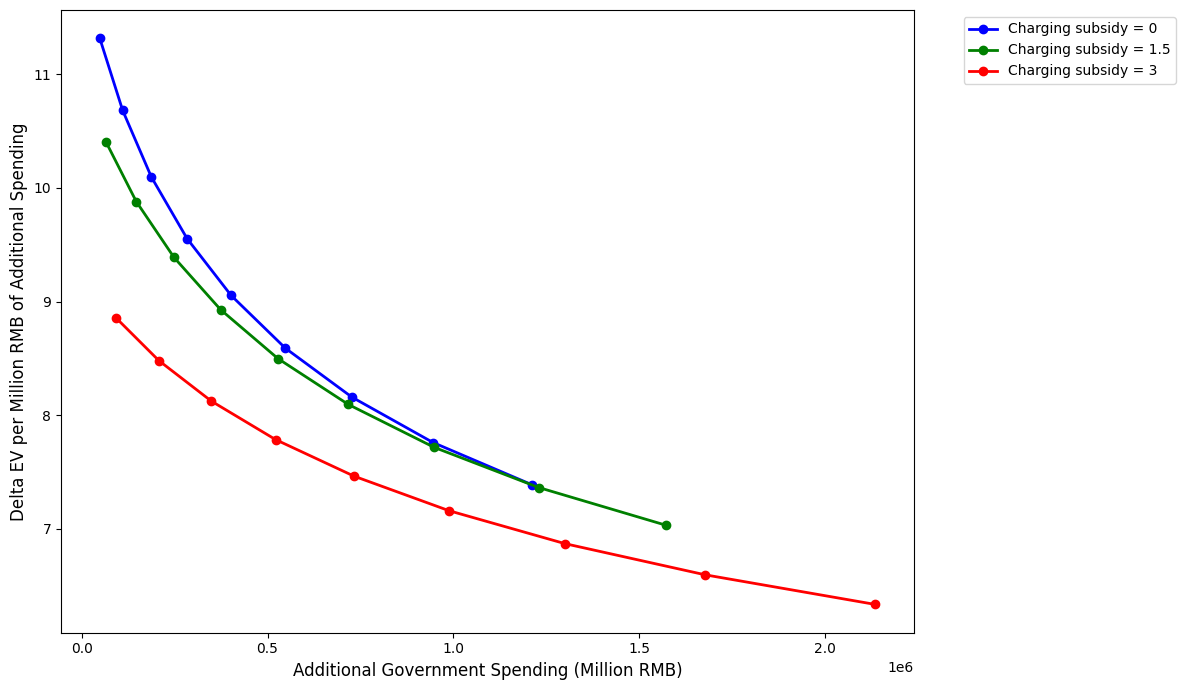

In [52]:
# Plot cost-effectiveness against additional spending
results_df = results_df.sort_values(['charging_subsidy', 'delta_spending_millions'])

# Select specific charging subsidy levels to show
selected_charging_levels = [0, 1.5, 3]
colors = ['blue', 'green', 'red']
labels = ['No charging subsidy', 'Medium charging subsidy', 'High charging subsidy']

# Create the plot
plt.figure(figsize=(12, 7))

for charging_level, color, label in zip(selected_charging_levels, colors, labels):
    # Get data for this charging subsidy level and exclude zero spending
    subset = results_df[
        (results_df['charging_subsidy'] == charging_level) & 
        (results_df['delta_spending_millions'] > 0)
    ].copy()
    subset = subset.sort_values('delta_spending_millions')
    
    # Plot delta_ev per million spent against delta_spending
    plt.plot(subset['delta_spending_millions'], 
             subset['ev_per_million'],
             color=color,
             label=f'Charging subsidy = {charging_level}',
             marker='o',
             linewidth=2,
             markersize=6)

plt.xlabel('Additional Government Spending (Million RMB)', fontsize=12)
plt.ylabel('Delta EV per Million RMB of Additional Spending', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
